<a id="contents"></a>
# ANALYSIS OF AGB DATA IN BELIGE DATASET

- [**DOWNLOAD SENTINEL DATA**](#download)
    - [**Select features**](#feature_sel)
- [**AGB TARGET VARIABLE ANALYSIS**](#target_var_analysis)
    - [**Target variable distribution**](#target_var_dist)
    - [**Check target variable variance**](#target_vari)
    - [**Check variance at site level groups**](#site_vari)
- [**Plot-level groups vs Site-level groups**](#groups)
    - [**Check outliers**](#check_outliers)
    - [**Box plot**](#boxplot)
    - [**Check Skew**](#check_skew)
    - [**Check High-AGB outlier concentraion**](#outlier_conc)
- [**EXPLORE SKEW REDUCTION METHODS**](#skew_red)
    - [**Explore potential tranformations**](#skew_trans)
    - [**Check log-transformation effects on skew**](#log_trans)
- [**CONCLUSION**](#conclusion)

In [1]:
# Import Packages
import os
import re
import sys
import time
import copy
from pathlib import Path
from IPython.display import display

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import boxcox

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import r2_score, mean_squared_error

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, GroupKFold
from sklearn.model_selection import RepeatedKFold

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, RidgeCV

from sklearn.feature_selection import VarianceThreshold

#%load_ext autoreload
#%reload_ext autoreload
#%autoreload 2
#from model_functions import *

%run Model_functions.ipynb

<a id="download"></a>
# DOWNLOAD DATA

In [2]:
SENTINEL_DATA_CSV        = "../../DATA/AGB_DATA/Merged_Data/Sentinel_AGB/AGB_SENTINEL_CANOPY.csv"
#SENINEL_MISSING_DATA_CSV = "../../DATA/AGB_DATA/Merged_Data/Sentinel_AGB/AGB_VAL_EO_SENTINEL.csv"

sentinel_df = pd.read_csv(SENTINEL_DATA_CSV)
print(sentinel_df.shape)
sentinel_df.columns

(8774, 34)


Index(['dataset', 'plot_id', 'start_date', 'end_date', 'latitude', 'longitude',
       'diameter', 'height', 'species', 'plant_AGB_kg', 'capture_start',
       'capture_end', 'sentinel_time', 'Blue', 'Green', 'Red', 'RE1', 'RE2',
       'RE3', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1',
       'NDRE2', 'NDRE3', 'CIrededge', 'CLOUD_COVERAGE', 'cloud_threshold_used',
       'simard_height_m', 'tandemx_height_m'],
      dtype='object')

In [3]:
sentinel_df['dataset'].unique()

array(['ElSalvador', 'Panama-Chirqui_2', 'CostaRica-Nicoya',
       'CostaRica-Sierpe', 'Belige', 'Panama-Chirqui_1',
       'Honduras-Blanca', 'Brazil-Mangue', 'Brazil-Furo_Do_Chato',
       'Brazil-Manguezal', 'Brazil-Maruipe', 'Brazil-AcarauBoca',
       'Brazil-BocaGrande', 'Brazil-Barreto', 'Brazil-Salinas',
       'Brazil-FuroGrande', 'Brazil-Caetano'], dtype=object)

<a id="feature_sel"></a>
## Select features

In [4]:
non_feature_cols = [
    #'plant_AGB_kg',        # Target variable
    #'dataset',             # metadata
    'start_date',          # metadata
    'end_date',            # metadata
    'capture_start',       # metadata
    'capture_end',         # metadata
    #'latitude',            # coordinate
    #'longitude',           # coordinate
    'diameter',            # Allometric
    'height',               # Allometric
    'cloud_threshold_used',
    'tandemx_height_m',
    'simard_height_m'
]
sentinel_bands = [
    'Blue', 'Green', 'Red'
]
sentinel_indices = [
    'NIR', 'SWIR1', 'SWIR2', 'NDVI',
    'MNDWI', 'NBR', 'EVI', 'CLOUD_COVERAGE'
]
useful_categorical = ['plot_id', 'species']
struct_features = ['height']

target = 'plant_AGB_kg'
feature_cols = [c for c in sentinel_df.columns if c not in non_feature_cols]

sentinel_df = sentinel_df[feature_cols]

print(f"Features: {sentinel_df.columns}")

Features: Index(['dataset', 'plot_id', 'latitude', 'longitude', 'species',
       'plant_AGB_kg', 'sentinel_time', 'Blue', 'Green', 'Red', 'RE1', 'RE2',
       'RE3', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1',
       'NDRE2', 'NDRE3', 'CIrededge', 'CLOUD_COVERAGE'],
      dtype='object')


In [14]:
belige_df = sentinel_df[sentinel_df['dataset'] == 'Belige']

y    = belige_df[target]
X_df = belige_df.drop(columns=['dataset', target]).copy()

# Let us start with the assumption that "plot_id" can be used for grouping of the data.
# These groups can potentially be used for grouped-Cross-Validation.
groups = X_df['plot_id'].copy()

In [6]:
for dataset_name in sentinel_df['dataset'].unique():
    data_df = sentinel_df[sentinel_df['dataset'] == dataset_name]
    n_plots = data_df['plot_id'].nunique()
    print(f"{dataset_name:30s} : {len(data_df)} rows, {n_plots} plots")

ElSalvador                     : 2857 rows, 144 plots
Panama-Chirqui_2               : 83 rows, 19 plots
CostaRica-Nicoya               : 313 rows, 82 plots
CostaRica-Sierpe               : 93 rows, 20 plots
Belige                         : 3880 rows, 59 plots
Panama-Chirqui_1               : 70 rows, 4 plots
Honduras-Blanca                : 797 rows, 24 plots
Brazil-Mangue                  : 88 rows, 1 plots
Brazil-Furo_Do_Chato           : 52 rows, 1 plots
Brazil-Manguezal               : 84 rows, 1 plots
Brazil-Maruipe                 : 59 rows, 1 plots
Brazil-AcarauBoca              : 60 rows, 1 plots
Brazil-BocaGrande              : 66 rows, 1 plots
Brazil-Barreto                 : 54 rows, 1 plots
Brazil-Salinas                 : 78 rows, 1 plots
Brazil-FuroGrande              : 52 rows, 1 plots
Brazil-Caetano                 : 88 rows, 1 plots


<a id="target_var_analysis"></a>
# TARGET VARIABLE ANALYSIS

Examine the following to understand skew in the AGB values:
 - Descriptive statistics
 - Zero proportion
 - Percentile spread

In [7]:
print(f"Unique plots    : {groups.nunique()}")
print(y[y > 0].describe())

print(f"\nZero AGB stats:")
print(f"----------------")
# Check the exact zero proportion
zero_count    = (y == 0).sum()
nonzero_count = (y > 0).sum()
print(f"Zero AGB rows    : {zero_count} ({100*zero_count/len(y):.1f}%)")

# Are zeros real measurements or missing data?
print("\nZero AGB plot distribution:")
print(X_df[y == 0]['plot_id'].value_counts().head(20))

# Are all plots zero or just some?
plot_agb = y.groupby(groups).agg(['mean', 'max', 'count'])
print("\nPlots with all-zero AGB:")
print((plot_agb['max'] == 0).sum(), "plots out of", len(plot_agb))

print(f"\nNon-zero AGB stats:")
print(f"--------------------")
print(f"  Non-zero AGB rows: {nonzero_count} ({100*nonzero_count/len(y):.1f}%)")

# AGB distribution of non-zero rows
print("\n  Non-zero AGB percentiles:")
percentiles = [10, 25, 50, 75, 90, 95, 99]
values      = np.percentile(y[y > 0], percentiles)
for pct, val in zip(percentiles, values):
    print(f"  {pct:>3}th percentile : {val:>5.4f} kg")
print(f"   {'max':>3}            : {y.max():>10.4f} kg")

Unique plots    : 59
count    3880.000000
mean        4.210759
std        16.762269
min         0.000150
25%         0.009292
50%         0.019160
75%         3.586931
max       427.217288
Name: plant_AGB_kg, dtype: float64

Zero AGB stats:
----------------
Zero AGB rows    : 0 (0.0%)

Zero AGB plot distribution:
Series([], Name: count, dtype: int64)

Plots with all-zero AGB:
0 plots out of 59

Non-zero AGB stats:
--------------------
  Non-zero AGB rows: 3880 (100.0%)

  Non-zero AGB percentiles:
   10th percentile : 0.0024 kg
   25th percentile : 0.0093 kg
   50th percentile : 0.0192 kg
   75th percentile : 3.5869 kg
   90th percentile : 9.0152 kg
   95th percentile : 16.4883 kg
   99th percentile : 64.3094 kg
   max            :   427.2173 kg


**3880 rows**  
 - Each row is one individual plant measurement in Belize.

**59 unique plots**  
 - The 3880 plants are distributed across 59 measurement plots.  
 - A plot is a physical area of ground where a researcher walked in and measured every tree.  
 - On average that is 66 plants per plot.

**AGB range 0.0 to 427.2 kg**
 - The lightest plant weighs essentially nothing (a seedling), the heaviest weighs 427 kg (a large mature mangrove tree).  
 - That is a 427,000x difference between the smallest and largest value in the dataset.

**AGB Mean: 4.21 kg**
 - The average is 4.21 kg, but the median is 0.019 kg
 - The mean is 220 times larger than the median
 - This only happens when a small number of extreme values pull the mean far away from where most of the data actually sits

**AGB Median: 0.019 kg**
 - This is the most important single number in the dataset
 - It tells you the typical plant in Belize is a very young seedling or sapling
 - More than half of all 3880 plants weigh less than 19 grams. These are seedlings and saplings.

**AGB std 16.8 kg** 
 - The average deviation from the mean is 16.8 kg.  
 - The standard deviation is 4x larger than the mean (4.2 kg)
 - In a normal distribution std and mean are in the same ballpark
 - A standard deviation that is 4x larger than the mean tells that the distribution is not bell-shaped — it is heavily skewed.
 - A few very large trees are pulling the mean up while the majority of plants cluster near zero.

**Min: 0.000150 kg**
 - The lightest plant weighs 0.15 grams
 - This could be a seedling

**Max: 427.22 kg**
 - The largest tree weighs 427 kg
 - This one tree is 100,000 times heavier than the lightest seedling in the dataset

**Zero AGB rows: 0**
 - There are no actual zero values in the dataset
 - Every plant has some biomass, even if it is tiny

**Distribution**  
Min    : 0.00015 kg  
25th % : 0.009 kg   <= most plants are tiny seedlings/saplings  
50th % : 0.019 kg   <= median is ~19 grams  
75th % : 3.59 kg    <= still very small  
90th % : 9.02 kg  
95th % : 16.49 kg  
99th % : 64.31 kg  
Max    : 427.22 kg  <= massive outlier pulling everything  

**What this means in plain terms**  
 - This is a classic extreme right-skewed distribution problem, not a zero-inflation problem.  
 - These are not samples from the same population in any practical sense.
 - A seedling and a 400 kg mangrove tree are at completely different stages of development and their AGB is controlled by completely different factors.

<a id="target_var_dist"></a>
## Target variable distribution
Four-panel visualization showing the extreme right skew in raw AGB values, the bulk of the data concentrated near zero, and how log(1+AGB)
transformation compresses the range into a workable distribution for modeling.

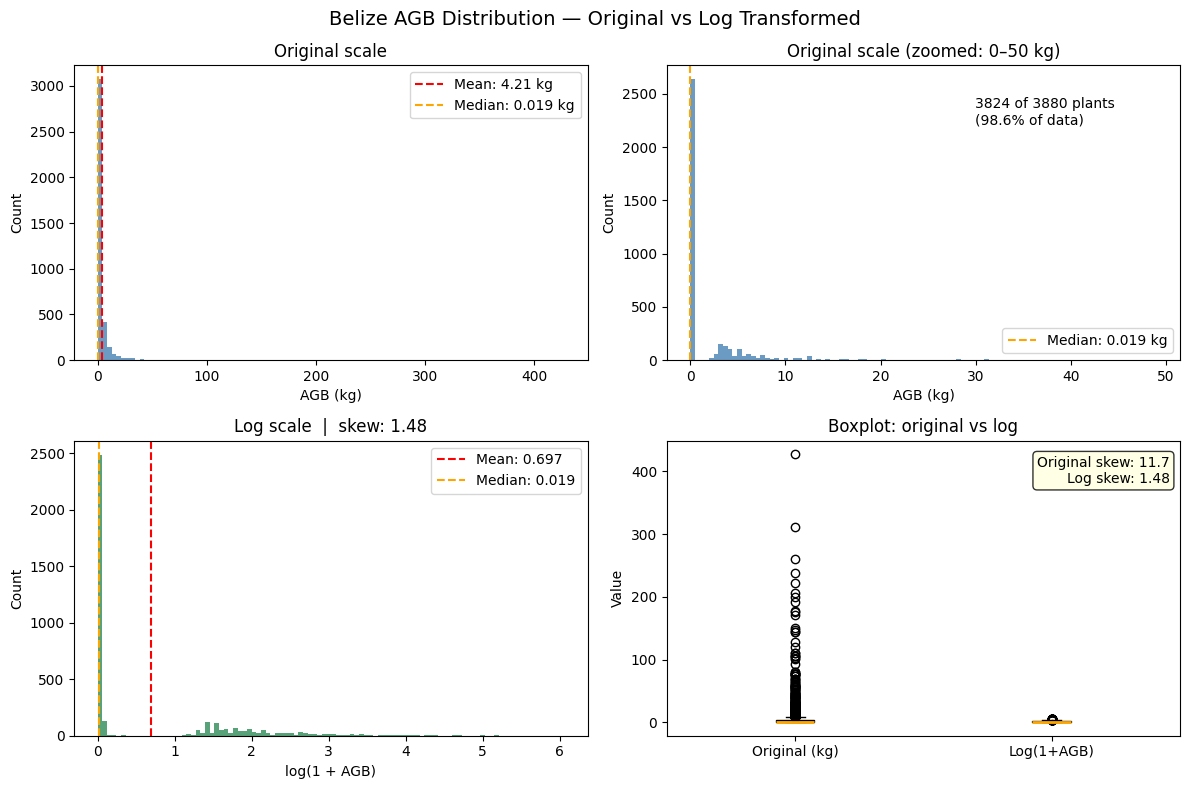

Original skew : 11.732
Log skew      : 1.483


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Belize AGB Distribution — Original vs Log Transformed', fontsize=14)

# --- Plot 1: Original scale histogram ---
ax1 = axes[0, 0]
ax1.hist(y, bins=100, color='steelblue', edgecolor='none', alpha=0.8)
ax1.axvline(y.mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'Mean: {y.mean():.2f} kg')
ax1.axvline(y.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {y.median():.3f} kg')
ax1.set_title('Original scale')
ax1.set_xlabel('AGB (kg)')
ax1.set_ylabel('Count')
ax1.legend()

# --- Plot 2: Original scale — zoomed into 0-50 kg to see the bulk ---
ax2 = axes[0, 1]
ax2.hist(y[y <= 50], bins=100, color='steelblue', edgecolor='none', alpha=0.8)
ax2.axvline(y.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {y.median():.3f} kg')
ax2.set_title('Original scale (zoomed: 0–50 kg)')
ax2.set_xlabel('AGB (kg)')
ax2.set_ylabel('Count')
ax2.legend()
ax2.annotate(f'{(y <= 50).sum()} of {len(y)} plants\n({100*(y<=50).mean():.1f}% of data)',
             xy=(0.6, 0.8), xycoords='axes fraction', fontsize=10)

# --- Plot 3: Log-transformed histogram ---
y_log = np.log1p(y)
ax3 = axes[1, 0]
ax3.hist(y_log, bins=100, color='seagreen', edgecolor='none', alpha=0.8)
ax3.axvline(y_log.mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'Mean: {y_log.mean():.3f}')
ax3.axvline(y_log.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {y_log.median():.3f}')
ax3.set_title(f'Log scale  |  skew: {y_log.skew():.2f}')
ax3.set_xlabel('log(1 + AGB)')
ax3.set_ylabel('Count')
ax3.legend()

# --- Plot 4: Boxplot side by side original vs log ---
ax4 = axes[1, 1]
data_to_plot = [y.values, y_log.values]
bp = ax4.boxplot(data_to_plot,
                 tick_labels=['Original (kg)', 'Log(1+AGB)'],
                 patch_artist=True,
                 medianprops=dict(color='orange', linewidth=2))
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('seagreen')
ax4.set_title('Boxplot: original vs log')
ax4.set_ylabel('Value')

# Annotate skew on boxplot
ax4.text(0.98, 0.95, f'Original skew: {y.skew():.1f}\nLog skew: {y_log.skew():.2f}',
         transform=ax4.transAxes,
         ha='right', va='top',
         fontsize=10,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('belize_agb_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Original skew : {y.skew():.3f}")
print(f"Log skew      : {y_log.skew():.3f}")

**Top left**
 - Full original distribution.
 - A massive spike of bars crammed against the left side near zero
 - A long flat tail stretching all the way to the right toward 427 kg
 - The extreme right tail will be visible as a long flat line stretching to 427 kg while almost all bars are crammed on the left near zero.
 - That long tail stretching to the right is the right skew.

The mean is 220 times larger than the median.  
The large trees on the right are dragging the mean away from where the bulk of the data sits.  
That gap between mean and median is the numerical signature of right skew.
**NOTE:** In a symmetric distribution the mean and median are at the same place. Here:

**Top right**
 - Zoomed into 0–50 kg to see where 98% of the data actually lives.

**Bottom left**
 - log-transformed distribution. Should look approximately bell-shaped with skew dropping from 11.7 to 1.5.

**Bottom right**
 - boxplot comparison.
 - The original scale box will be almost invisible against its own outliers.
 - The log-transformed box will show a proper interquartile range.

<a id="target_vari"></a>
## Check target variable variance

In [9]:
# How many rows drive the variance
print(f"\nDisplay variance in AGB:")
thresholds = [10, 50, 100, 200]
for t in thresholds:
    above     = y[y >  t]
    below     = y[y <= t]
    var_above = above.var()
    var_below = below.var()
    ratio     = var_above / var_below if var_below > 0 else float('nan')

    print(f"  AGB > {t} kg")
    print(f"    Above {t} kg : {len(above):>5} rows ({100*len(above)/len(y):.2f}%) | var = {var_above:.1f}")
    print(f"    Below {t} kg : {len(below):>5} rows ({100*len(below)/len(y):.2f}%) | var = {var_below:.1f}")
    print(f"    Ratio        : {ratio:.1f}x")

# Log-transform diagnostics
log_y = np.log1p(y)
print(f"\nLog-transformed AGB:")
print(f"  mean : {log_y.mean():.3f}")
print(f"  std  : {log_y.std():.3f}")
print(f"  skew : {log_y.skew():.3f}")
print(f"\nOriginal AGB skew: {y.skew():.3f}")


Display variance in AGB:
  AGB > 10 kg
    Above 10 kg :   354 rows (9.12%) | var = 2065.7
    Below 10 kg :  3526 rows (90.88%) | var = 5.2
    Ratio        : 394.6x
  AGB > 50 kg
    Above 50 kg :    56 rows (1.44%) | var = 5492.8
    Below 50 kg :  3824 rows (98.56%) | var = 34.8
    Ratio        : 157.8x
  AGB > 100 kg
    Above 100 kg :    24 rows (0.62%) | var = 6045.9
    Below 100 kg :  3856 rows (99.38%) | var = 67.8
    Ratio        : 89.2x
  AGB > 200 kg
    Above 200 kg :     6 rows (0.15%) | var = 6712.4
    Below 200 kg :  3874 rows (99.85%) | var = 156.9
    Ratio        : 42.8x

Log-transformed AGB:
  mean : 0.697
  std  : 1.089
  skew : 1.483

Original AGB skew: 11.732


**Variance**
 - Variance measures how spread out the values are from each other.
 - High variance means the values are far apart.
 - Low variance means the values are clustered together.

**In the above output:**
 - As we remove the smaller trees and keep only the larger ones, the variance keeps increasing.
 - This confirmed that the 6 rows above 200 kg have more variance (6712) than the entire bottom 99% of the dataset combined.
 - Those 6 trees are driving the model's loss function almost entirely.  

**What this means in plain terms?**  
 - The 6 heaviest trees are 42.8 times more spread out from their own mean than the remaining 3874 plants are from their mean.
 - Those 6 trees represent 0.15% of the data but their internal variance is 42.8x larger than the variance of the other 99.85%.

<a id="site_vari"></a>
## Check variance at site level groups

In [10]:
site_var_contribution = y.groupby(
    groups.map(lambda x: x.rsplit('_', maxsplit=1)[0])
).agg(
    n_rows   = 'count',
    sum_agb  = 'sum',
    var_agb  = 'var',
    mean_agb = 'mean'
)
site_var_contribution['pct_total_variance'] = (
    site_var_contribution['var_agb'] * site_var_contribution['n_rows'] /
    (site_var_contribution['var_agb'] * site_var_contribution['n_rows']).sum() * 100
).round(1)
print(site_var_contribution.sort_values('pct_total_variance', ascending=False))

                  n_rows      sum_agb      var_agb   mean_agb  \
plot_id                                                         
Channel Caye         449  6127.316637  1580.282983  13.646585   
New River             57  2621.723315  2549.743361  45.995146   
Drowned Caye         380  3393.787565    77.854525   8.931020   
Payne's Creek        514  1592.545949    32.469235   3.098338   
Gra Gra Lagoon       453  1104.111314    21.995205   2.437332   
Turneffe Atoll       495   950.306138     8.188390   1.919810   
Hicks Caye           162   324.088259    12.099332   2.000545   
Big Creek            392   194.546822     2.889230   0.496293   
Frenchman Caye       605    22.106484     0.000869   0.036540   
Shipstern Lagoon     373     7.211999     0.002680   0.019335   

                  pct_total_variance  
plot_id                               
Channel Caye                    77.3  
New River                       15.8  
Drowned Caye                     3.2  
Payne's Creek           

**COMMENTS:**
**93.1% of total variance comes from just two sites:**
 - Channel Caye  : 77.3% of variance,  449 rows
 - New River     : 15.8% of variance,   57 rows
 - Combined      : 93.1% of variance,  506 rows (13% of data)
 - Everything else:  6.9% of variance, 3374 rows (87% of data)

**What this means in plain terms?**  
 - This means the model's loss function is almost entirely determined by how well it predicts the above two sites.
 - The remaining 3374 rows from 8 sites contribute only 6.9% of variance — the model learns almost nothing useful from them because their AGB values are so similar (near-zero) that any prediction close to zero scores well.

**New River:**
 - Highest variance per row (2549) of all 10 sites, with only 57 rows across 5 plots
 - With plot-level grouped CV, each New River plot is held out exactly once as a test fold
 - Whether 57 rows is sufficient for the model to learn the New River AGB pattern is answered by the New River fold score 

**Frenchman Caye and Shipstern Lagoon:**
 - 978 rows contributing 0.0% of variance.
 - Every plant in these two sites has AGB below 1 kg — their values are so tightly clustered that they add no variance signal to the loss function
 - They are present in training data but the MSE loss assigns them negligible weight compared to high-AGB rows.

**CONCLUSION:**
 - If variance were spread evenly across all 10 sites, the raw AGB values would be learnable as-is.  
 - But seeing that 93.1% of variance is concentrated in just 2 sites confirmed that the target distribution is too skewed for a model to learn reliably in original scale.
 - Based on this skew, it appears that a log transformation of AGB data is needed.

<a id="plot_vari"></a>
## Check variance at plot-level groups

In [15]:
def plot_group_variance(df, target_col='plant_AGB_kg', plot_col='plot_id'):
    import matplotlib.pyplot as plt
    import numpy as np

    stats = (df.groupby(plot_col)[target_col]
               .agg(mean='mean', std='std', count='count')
               .reset_index()
               .sort_values('mean', ascending=False)
               .reset_index(drop=True))

    fig, ax = plt.subplots(figsize=(14, 8))
    ax.barh(stats[plot_col], stats['mean'], xerr=stats['std'],
            color='steelblue', alpha=0.8, capsize=3)
    ax.set_xlabel('AGB (kg)')
    ax.set_title('Plot-level AGB — Mean ± Std')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

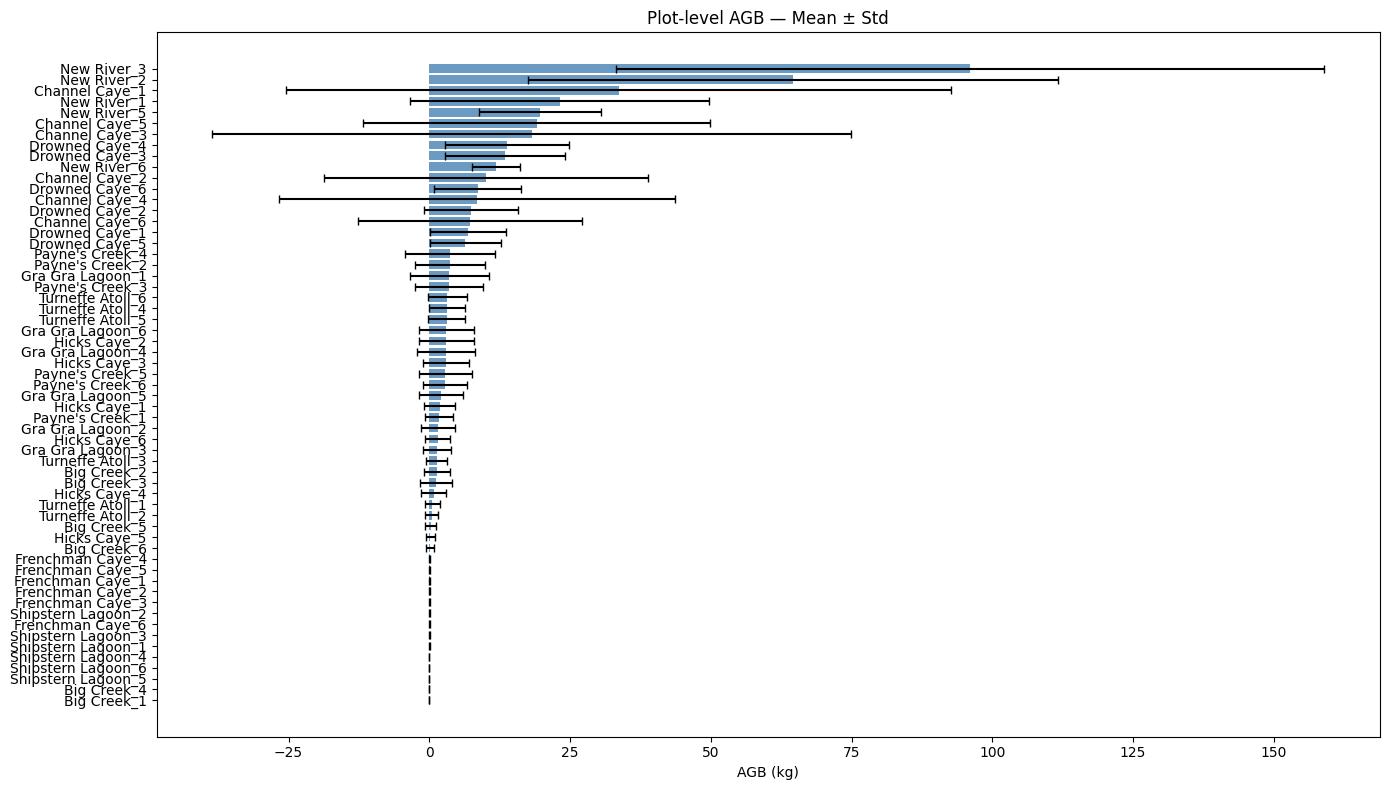

In [16]:
plot_group_variance(belige_df)

<a id="groups"></a>
## Plot-level groups vs Site-level groups

In [13]:
site_groups = groups.map(lambda x: x.rsplit('_', maxsplit=1)[0])
print(f"\nSite-level groups: {site_groups.nunique()} sites")
print(site_groups.value_counts())


Site-level groups: 10 sites
plot_id
Frenchman Caye      605
Payne's Creek       514
Turneffe Atoll      495
Gra Gra Lagoon      453
Channel Caye        449
Big Creek           392
Drowned Caye        380
Shipstern Lagoon    373
Hicks Caye          162
New River            57
Name: count, dtype: int64


**COMMENTS:**  

**Hierarchy**  
Site (multiple per dataset)  
└── Plots (multiple per site)  
      └── Individual plants (multiple per plot)  

**Site-level groups**
 - 10 groups, variance reasonably spread across 8 sites after log transform.  
 - Each fold holds out one entire site. Clean and interpretable.  

**Plot-level groups**
  - 59 groups, variance spread across many plots.
  - Channel Caye plots dominate the top of the list but the spread is much more granular.

<a id="check_outliers"></a>
# Check for outliers

<a id="boxplot"></a>
## Box plot

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 6))
fig.suptitle('Belize AGB — Outlier Distribution', fontsize=14)

y_log = np.log1p(y)

# --- Plot 1: Original scale boxplot ---
ax1 = axes[0]
bp1 = ax1.boxplot(y.values,
                  patch_artist=True,
                  medianprops=dict(color='orange', linewidth=2),
                  flierprops=dict(marker='o', markerfacecolor='red',
                                  markersize=4, alpha=0.5))
bp1['boxes'][0].set_facecolor('steelblue')
ax1.set_title(f'Original scale\nskew: {y.skew():.2f}')
ax1.set_ylabel('AGB (kg)')
ax1.set_xticks([1])
ax1.set_xticklabels(['AGB (kg)'])

# Annotate the max outlier
ax1.annotate(f'Max: {y.max():.1f} kg',
             xy=(1, y.max()),
             xytext=(1.15, y.max() * 0.95),
             fontsize=9,
             arrowprops=dict(arrowstyle='->', color='black'))

# --- Plot 2: Log-transformed boxplot ---
ax2 = axes[1]
bp2 = ax2.boxplot(y_log.values,
                  patch_artist=True,
                  medianprops=dict(color='orange', linewidth=2),
                  flierprops=dict(marker='o', markerfacecolor='red',
                                  markersize=4, alpha=0.5))
bp2['boxes'][0].set_facecolor('seagreen')
ax2.set_title(f'Log scale\nskew: {y_log.skew():.2f}')
ax2.set_ylabel('log(1 + AGB)')
ax2.set_xticks([1])
ax2.set_xticklabels(['log(1 + AGB)'])

# Annotate the max outlier
ax2.annotate(f'Max: {y_log.max():.2f}',
             xy=(1, y_log.max()),
             xytext=(1.15, y_log.max() * 0.98),
             fontsize=9,
             arrowprops=dict(arrowstyle='->', color='black'))

plt.tight_layout()
plt.savefig('belize_agb_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

<a id="check_skew"></a>
## Check Skew
Skewness is a single number that measures how asymmetric a distribution is around its mean.  
A perfectly normal distribution would have skew of 0.  

**Formula**
 - skewness = mean of ((x - mean) / std)³

The cubing does two things:  
 - Preserves the sign — values above mean contribute positive, below mean contribute negative
 - Amplifies large deviations — values far from the mean dominate the result

**Interpretatio of skew value:**  
Skew = 0  => perfectly symmetric (normal distribution)  
Skew > 0  => right-skewed (tail on the right)  
Skew < 0  => left-skewed (tail on the left)  

In [ ]:
y.skew()

**COMMENTS:**  
A skew of 11.7 means the distribution is severely asymmetric — confirmed visually by the long right tail in the histogram.

<a id="outlier_conc"></a>
## Check High-AGB outlier concentraion

**NEXT STEP:**  
 - It is confirmed that the top 6 trees (AGB > 200 kg) had 42.8x more variance than the rest.
 - Identify which plots and sites contain extreme biomass values (AGB > 100 kg) to determine whether high-variance trees are scattered across the dataset or clustered in specific locations.

**Why this matters?**  
 - This matters because of how grouped CV works.
 - In grouped CV, entire plots are held out as test folds.
 - If the extreme trees are spread across many plots, the model will always see some high-AGB examples in training regardless of which plot is held out. But if they are all concentrated in 2-3 plots, then whenever those specific plots land in the test fold, the model has never seen that AGB range in training and will fail catastrophically.

In [ ]:
# Check which plots contain the extreme outliers
extreme_mask = y > 100
print("Plots with AGB > 100 kg:")
print(X_df[extreme_mask]['plot_id'].value_counts())

# Check if extreme values cluster in specific plots
# If 6 extreme rows all come from 1-2 plots, grouped CV
# will always fail when those plots are in the test fold
plot_max_agb = y.groupby(groups).max().sort_values(ascending=False)
print("\nTop 10 plots by max AGB:")
print(plot_max_agb.head(10))

**COMMENTS:**  
 - The extreme AGB values are concentrated in exactly two site clusters — Channel Caye and New River.  
 - **Channel Caye plots:** 6 plots, max AGB 427 kg
 - **New River plots   :** 3 plots, max AGB 261 kg
 - **Everything else   :** max AGB ~69 kg

**Theory**  
 - It is possible that Channel Caye and New River are ecologically distinct from the other sites — the data shows they contain all trees above 100 kg while no other site exceeds 61 kg.  
 - It could be forest age, species composition, soil type, hydrology, or some combination.  
 - Field notes or published literature about these specific sites would be needed to make that determination."

**What grouped CV is doing?**  
 - Grouped CV is asking: if I train on these plots and test on a completely unseen plot, how well does the model perform?

**Why the above skew-phenomenon affects grouped CV**
 - With 59 total plots and 10-fold grouped CV, each fold holds ~6 plots.
 - When Channel Caye is held out — the model has never seen AGB above 261 kg (New River's max) in training. It needs to extrapolate into unknown territory.
 - When New River is held out — the model has never seen AGB above 170 kg (Channel Caye_5's max without New River) in training.

**What effects are felt?**  
 - The skew makes the scores look bad but that is not the same as grouped CV being wrong.
 - Near-zero variance in the holdout set makes R² mathematically unstable.
 - This is a metric problem, not a grouped CV problem.
 — R² just cannot handle near-zero variance targets.

**If there is such an issue, why dont we drop grouped-CV?**  
 - If you used regular CV instead, plot measurements from the same physical location would appear in both train and test folds.
 - The model would memorize plot-specific spectral signatures rather than learning generalizable AGB patterns.
 - Regular CV scores would look better but would be meaningless — you would be measuring memorization, not generalization.

<a id="skew_red"></a>
# EXPLORE SKEW REDUCTION METHODS

<a id="skew_trans"></a>
## Explore potential tranformations

Skew can be addressed using one of the following methods by compressing the scale.  
**Square root:** mild compression  
**Log:** stronger compression  
**Box-Cox:** finds the optimal transformation mathematically.  
 - Box-Cox tries all possible power transformations and finds the lambda that minimizes skew.
 - When lambda = 0 it reduces to log. When lambda = 0.5 it reduces to square root.  

**Log transformation is the correct choice for three reasons:**  
**Skew is 11.7**  
 - Square root is too mild for this level of skew.
 - Box-Cox would likely find a lambda close to 0, meaning it would converge to log anyway.

**Data has near-zero values**  
 - np.log1p(y) handles values close to zero safely.
 - Box-Cox requires strictly positive values and the +1 adjustment is essentially the same as log1p.

**interpretability**  
 - Log transformation has a direct biological interpretation — it linearizes multiplicative growth relationships, which is exactly how tree biomass accumulates over time.
 - Square root and Box-Cox have no such natural interpretation for AGB data.

**NEXT STEP:**  
 - Verify whether log(1+AGB) transformations resolves the 93.1% variance concentration seen in original scale, and confirm site-level grouping for cross-validation.

In [ ]:
y_sqrt    = np.sqrt(y)
y_log     = np.log1p(y)
y_bc, lam = boxcox(y + 1)

print(f"Original skew  : {y.skew():.3f}")
print(f"Sqrt skew      : {y_sqrt.skew():.3f}")
print(f"Log skew       : {y_log.skew():.3f}")
print(f"Box-Cox skew   : {pd.Series(y_bc).skew():.3f}")
print(f"Box-Cox lambda : {lam:.3f}")

**COMMENTS:**
 - Box-Cox achieved the lowest skew (0.796)

**Why log is still the better choice despite higher skew**?  
 - Box-Cox lambda = -1.079 is not interpretable.
 - Box-Cox is not reversible in a simple way.

<a id="log_trans"></a>
## Check log-transformation effects on skew

In [ ]:
# Log-transform the target — non-negotiable given 11.7 skew
y_log = np.log1p(y)
print("Log-transformed AGB distribution:")
print(y_log.describe())
print(f"Skew after log: {y_log.skew():.3f}")

# Check log-transformed variance contribution per site
site_var_log = np.log1p(y).groupby(site_groups).agg(
    n_rows  = 'count',
    var_agb = 'var',
    mean    = 'mean'
)
site_var_log['pct_variance'] = (
    site_var_log['var_agb'] * site_var_log['n_rows'] /
    (site_var_log['var_agb'] * site_var_log['n_rows']).sum() * 100
).round(1)
print("\nVariance contribution after log transform:")
print(site_var_log.sort_values('pct_variance', ascending=False))

print("\nSummary")
print("-------")
print(f"Target       : log(1 + AGB)")
print(f"Groups       : site-level ({site_groups.nunique()} sites)")
print(f"CV folds     : 10 (leave-one-site-out)")
print(f"Rows         : {len(y_log)}")
print(f"y_log range  : {y_log.min():.3f} — {y_log.max():.3f}")
print(f"y_log skew   : {y_log.skew():.3f}")

**COMMENTS**  

**Before log transform:**  
 - Channel Caye  77.3%  <= dominates everything
 - New River     15.8%
 - Rest           6.9%

**After log transform:**  
 - Channel Caye  34.0%  <= still highest but manageable
 - Payne's Creek 16.2%  <= now second most important
 - Drowned Caye  13.6%
 - Gra Gra Lagoon 13.5%
 - Turneffe Atoll 11.5%
 - Hicks Caye     4.2%
 - Big Creek      3.5%
 - New River      3.5%  <= dropped from 15.8% to 3.5%'
 - Frenchman Caye 0.0%
 - Shipstern      0.0%

**What changed and why?**
 - Seven sites now contribute meaningfully to variance.
 - Before log transform, only Channel Caye and New River mattered.
 - Now Payne's Creek, Drowned Caye, Gra Gra Lagoon and Turneffe Atoll each contribute 11–16%.

**Frenchman Caye and Shipstern remain 0.0%:**
 - 978 rows of near-zero AGB that contribute nothing regardless of transformation.
 - These are structural noise — every plant weighs between 0.001 and 1 kg, and in log space the variance is effectively zero.

**CONCLUSION**
 - After log transformation, 8 out of 10 sites contribute meaningfully to variance.
 - With 10 sites and grouped CV set to 10 folds, each fold holds out exactly one site.

<a id="conclusion"></a>
# CONCLUSION

**Transformation**:
 - Log tranformation will be used for all subsequent Belize experiments.

**With Frenchman Caye and Shipstern contributing 0.0% variance:**
 - the two folds holding those sites out will score artificially high.
 - the model trivially predicts near-zero and gets credit for it.
 - Watch for this pattern.

**Fold holding out Frenchman Caye:** likely R² > 0.5  (easy fold)  
**Fold holding out Shipstern     :** likely R² > 0.5  (easy fold)  
**Fold holding out Channel Caye  :** hardest fold, watch this one  
**Fold holding out New River     :** second hardest

**Proof from experiments:**   
Fold 1  | Frenchman Caye  | CV: -0.099   ← predicted > 0.5, got negative  
Fold 5  | Channel Caye    | CV:  0.413   ← predicted hardest, got one of the best  
Fold 10 | New River       | CV:  0.275   ← predicted second hardest, got positive

In [ ]:
# See exactly which site each grouped CV fold corresponds to
site_groups = groups.map(lambda x: x.rsplit('_', maxsplit=1)[0])
gkf         = GroupKFold(n_splits=10)

X_current = X_df[['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'RE1', 'RE2']].copy()
X_current = pd.get_dummies(X_current, columns=['species'], dtype=int)

for fold, (train_idx, test_idx) in enumerate(gkf.split(X_current, y_log, site_groups)):
    site_held_out = site_groups.iloc[test_idx].unique()[0]
    y_test_fold   = y_log.iloc[test_idx]
    print(f"Fold {fold+1:2d} | site: {site_held_out:20s} | "
          f"n={len(test_idx):4d} | "
          f"AGB range: {np.expm1(y_test_fold.min()):.2f} — "
          f"{np.expm1(y_test_fold.max()):.2f} kg")

In [ ]:
fold_scores = np.array([-0.099, 0.108, 0.360, 0.004, 0.413,
                         0.563, 0.519, 0.301, 0.329, 0.275])

fold_sites  = ['Frenchman Caye', 'Payne\'s Creek', 'Turneffe Atoll',
               'Gra Gra Lagoon', 'Channel Caye', 'Big Creek',
               'Drowned Caye', 'Shipstern Lagoon', 'Hicks Caye', 'New River']

# Near-zero variance sites — R² is not meaningful here
exclude = ['Frenchman Caye', 'Gra Gra Lagoon']

mask          = np.array([s not in exclude for s in fold_sites])
valid_scores  = fold_scores[mask]

print("Excluded folds (near-zero variance):")
for s, sc in zip(np.array(fold_sites)[~mask], fold_scores[~mask]):
    print(f"  {s:20s} : {sc:.3f}")

print(f"\nValid folds ({mask.sum()} sites):")
for s, sc in zip(np.array(fold_sites)[mask], valid_scores):
    print(f"  {s:20s} : {sc:.3f}")

print(f"\nGrouped CV mean (all 10)   : {fold_scores.mean():.3f}")
print(f"Grouped CV mean (8 valid)    : {valid_scores.mean():.3f}")
print(f"Grouped CV std  (8 valid)    : {valid_scores.std():.3f}")
print(f"Min valid fold               : {valid_scores.min():.3f}")

In [ ]:
frenchman_y = y_log[site_groups == 'Frenchman Caye']
print(f"Frenchman Caye y_log variance : {frenchman_y.var():.6f}")
print(f"Frenchman Caye y_log std      : {frenchman_y.std():.6f}")
print(f"Frenchman Caye y_log range    : {frenchman_y.min():.4f} — {frenchman_y.max():.4f}")

Frenchman Caye y_log range : 0.0017 — 0.2302
                           = 0.002 — 0.26 kg in original scale

Every single plant in Frenchman Caye weighs between 2 grams and 260 grams.

R² on this fold is mathematically meaningless. When the target has variance 0.00075, the denominator of R² is near zero and any prediction scatter — however small — produces a large negative value. A model predicting exactly 0.019 kg (the dataset median) for every plant would score R² = -∞ on this fold.